# Import the libraries:

In [24]:
# Import the libraries
import pandas as pd                    # For creating, storing and manipulating DataFrames.
import numpy as np                     # For working with arrays.
import matplotlib.pyplot as plt        # For creating static, interactive, and animated visualizations.
import seaborn as sns                  # For creating statistical graphics.

# Load the Cleaned Data:

In [27]:
# Load the cleaned dataset
df = pd.read_csv("C:\\Users\\kishr\\Desktop\\70\\Takeo 70\\Covid 19 Project\\WHO-COVID-19-global-data-cleaned.csv")

In [29]:
df

,Date_reported,Country_code,Country,WHO_region,New_cases,Cumulative_cases,New_deaths,Cumulative_deaths
0,2020-01-03,AF,Afghanistan,EMRO,0,0,0,0
1,2020-01-04,AF,Afghanistan,EMRO,0,0,0,0
2,2020-01-05,AF,Afghanistan,EMRO,0,0,0,0
3,2020-01-06,AF,Afghanistan,EMRO,0,0,0,0
4,2020-01-07,AF,Afghanistan,EMRO,0,0,0,0
...,...,...,...,...,...,...,...,...
260855,2023-09-23,ZW,Zimbabwe,AFRO,0,265748,0,5718
260856,2023-09-24,ZW,Zimbabwe,AFRO,0,265748,0,5718
260857,2023-09-25,ZW,Zimbabwe,AFRO,0,265748,0,5718
260858,2023-09-26,ZW,Zimbabwe,AFRO,0,265748,0,5718


In [31]:
df.isnull().sum()     # Check for missing values

Date_reported        0
Country_code         0
Country              0
WHO_region           0
New_cases            0
Cumulative_cases     0
New_deaths           0
Cumulative_deaths    0
dtype: int64

In [33]:
df.dtypes

Date_reported        object
Country_code         object
Country              object
WHO_region           object
New_cases             int64
Cumulative_cases      int64
New_deaths            int64
Cumulative_deaths     int64
dtype: object

# Trend Analysis:

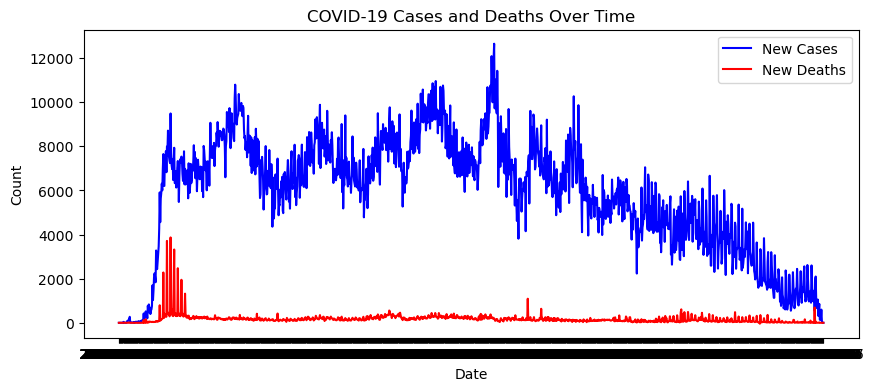

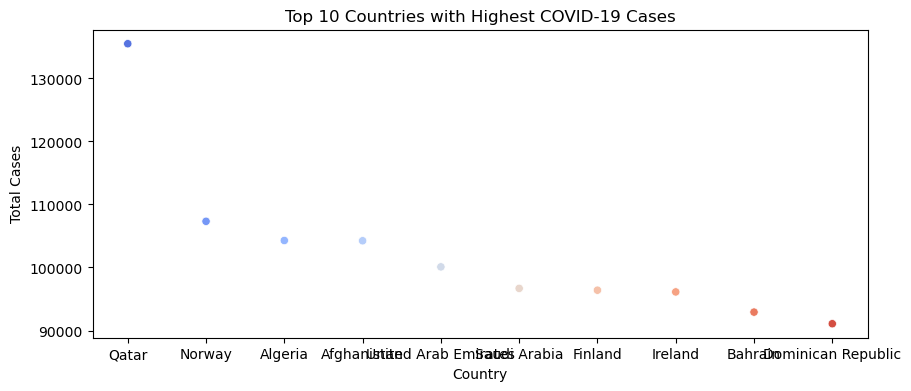

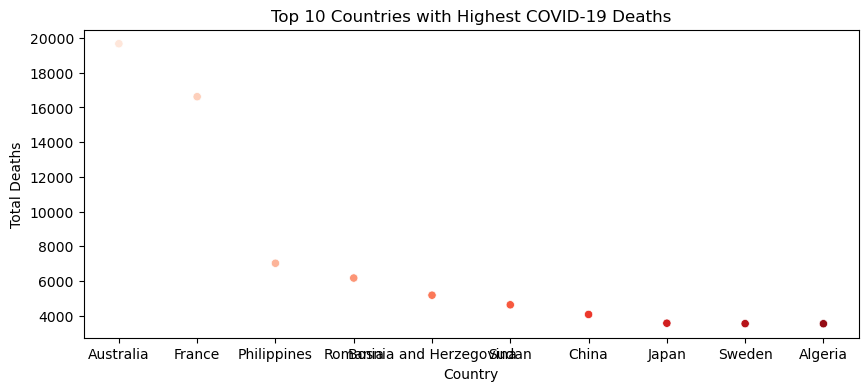

In [36]:
# New Cases and Deaths Over Time


cases_by_date = df.groupby("Date_reported")["New_cases"].sum()
deaths_by_date = df.groupby("Date_reported")["New_deaths"].sum()

plt.figure(figsize=(10,4))
plt.plot(cases_by_date, label="New Cases", color='blue')
plt.plot(deaths_by_date, label="New Deaths", color='red')
plt.xlabel("Date")
plt.ylabel("Count")
plt.title("COVID-19 Cases and Deaths Over Time")
plt.legend()


# Top 10 Countries with Highest Cases
top_countries_cases = df.groupby("Country")["New_cases"].sum().nlargest(10)

plt.figure(figsize=(10,4))
sns.scatterplot(x=top_countries_cases.index, y=top_countries_cases.values, hue=top_countries_cases.index, palette="coolwarm", legend=False)
plt.xlabel("Country")
plt.ylabel("Total Cases")
plt.title("Top 10 Countries with Highest COVID-19 Cases")


# Top 10 Countries with Highest Deaths
top_countries_deaths = df.groupby("Country")["New_deaths"].sum().nlargest(10)
plt.figure(figsize=(10,4))

sns.scatterplot(x=top_countries_deaths.index, y=top_countries_deaths.values, hue=top_countries_deaths.index, palette="Reds", legend=False)
plt.xlabel("Country")
plt.ylabel("Total Deaths")
plt.title("Top 10 Countries with Highest COVID-19 Deaths")
plt.show()

# Top 10 Countries with Highest Cases & Deaths:

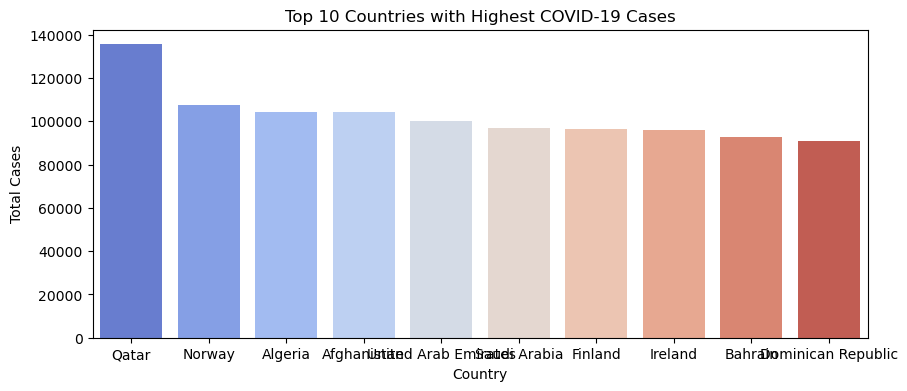

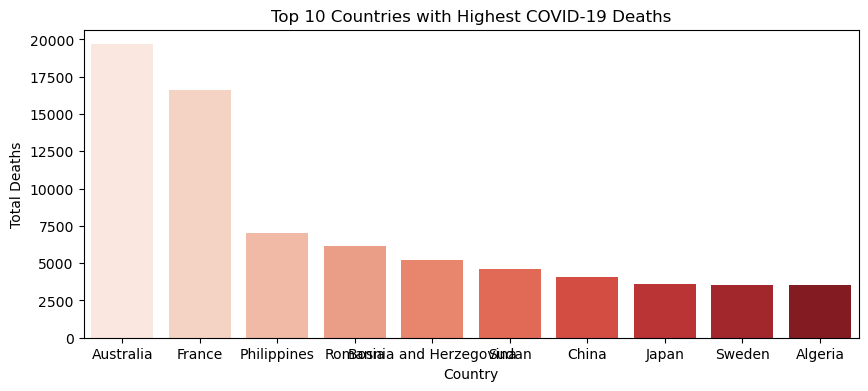

In [15]:
# Top 10 Countries with Highest Cases

top_countries_cases = df.groupby("Country")["New_cases"].sum().nlargest(10)

plt.figure(figsize=(10,4))
sns.barplot(x=top_countries_cases.index, y=top_countries_cases.values, hue=top_countries_cases.index, palette="coolwarm", legend=False)

plt.xlabel("Country")
plt.ylabel("Total Cases")
plt.title("Top 10 Countries with Highest COVID-19 Cases")


# Top 10 Countries with Highest Deaths
top_countries_deaths = df.groupby("Country")["New_deaths"].sum().nlargest(10)

plt.figure(figsize=(10,4))
sns.barplot(x=top_countries_deaths.index, y=top_countries_deaths.values, hue=top_countries_deaths.index, palette="Reds", legend=False)

plt.xlabel("Country")
plt.ylabel("Total Deaths")
plt.title("Top 10 Countries with Highest COVID-19 Deaths")
plt.show()

# Correlation Analysis:

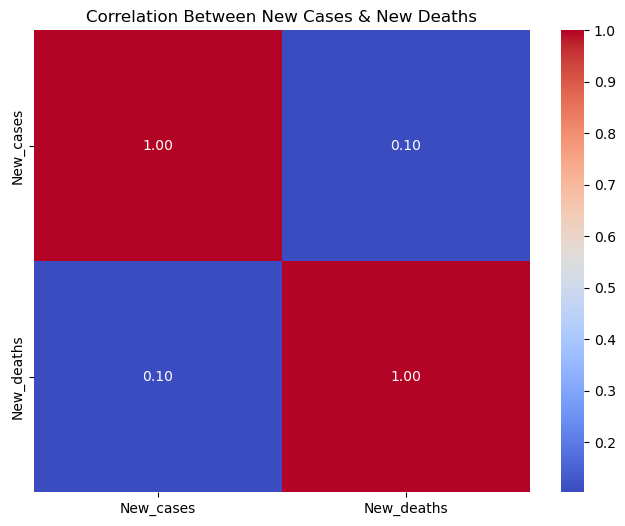

In [17]:
# Correlation between cases and deaths
plt.figure(figsize=(8,6))
sns.heatmap(df[['New_cases', 'New_deaths']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Between New Cases & New Deaths")
plt.show()


In [18]:
# Save the dataset for visualization 
df.to_csv("WHO-COVID-19-global-data-EDA.csv", index=False)